# Problem Setup V0=1

Training Complete


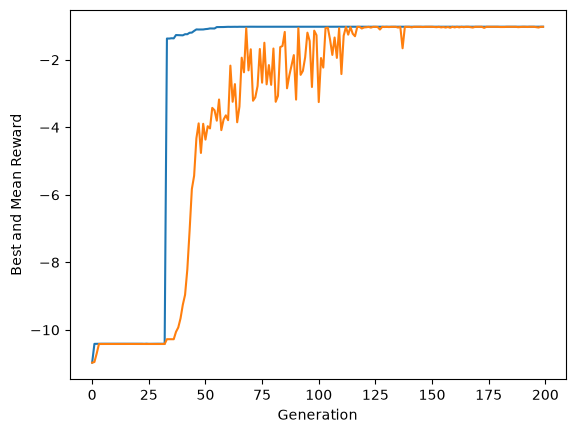

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

VelField = SRFlow()
CFG = SR_CONFIG.copy()

best_policy, rewards, mean_rewards = train_ga(CFG, VelField, shared=False, generations=200, population_size=320, start_episodes=2, n_workers=80)

print("Training Complete")
plot_rewards(rewards, mean_rewards, show_result=True)
plt.ioff()
plt.show()

### Model Evaluation

Success probability : 1.0000
Mean success time: 1.0231


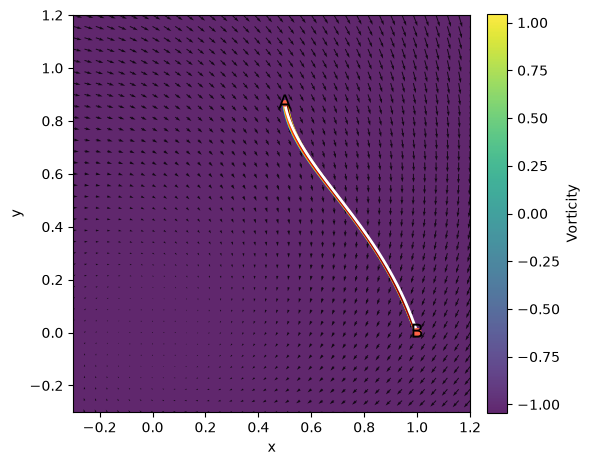

In [2]:
import h5py

env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=5000)

success_probability = np.mean([r["success"] for r in results])
mean_success_time = np.mean([r["time"] for r in results if r["success"]])

print(f"Success probability : {success_probability:.4f}")
print(f"Mean success time: {mean_success_time:.4f}")

track_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x_opt = f["x_sr"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y_opt = f["y_sr"]
    track_opt = np.stack((x_opt, y_opt), axis=1)

trajectories = [r["trajectory"] for r in results]
plot_trajectories(env, trajectories[0:10] + [track_opt], time=mean_success_time)

# Problem Setup V0=0.5

Training Complete


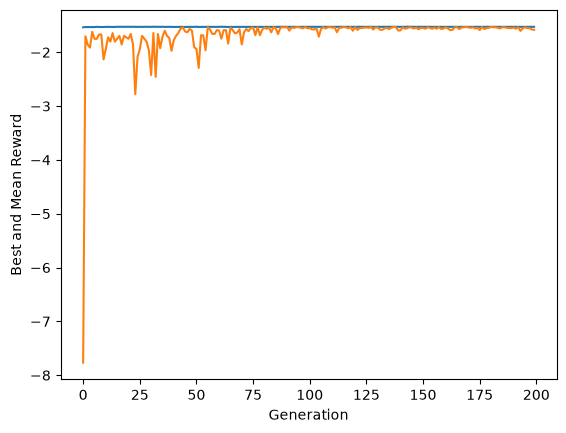

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [3]:
VelField = SRFlow()
CFG2 = SR_CONFIG.copy()
CFG2["Va"]=0.5

best_policy2, rewards2, mean_rewards2 = train_ga(CFG2, VelField, shared=False, generations=200, population_size=320, start_episodes=2, n_workers=80)

print("Training Complete")
plot_rewards(rewards2, mean_rewards2, show_result=True)
plt.ioff()
plt.show()

### Model Evaluation

Success probability : 1.0000
Mean success time: 1.5298


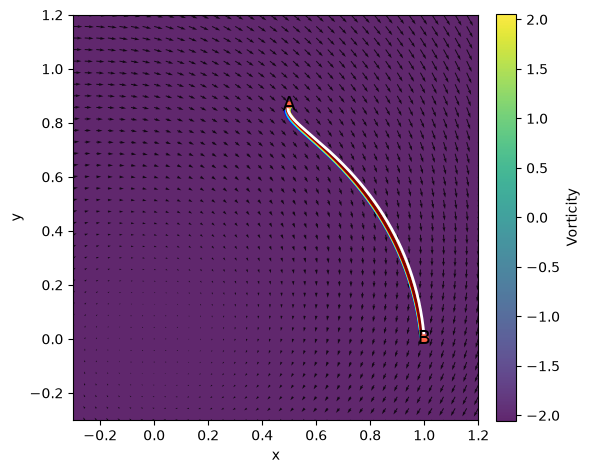

In [4]:
env2 = ZermeloEnv(CFG2, VelField)
results2 = evaluate_policy(model=best_policy2, env=env2, n_eval=5000)

success_probability2 = np.mean([r["success"] for r in results2])
mean_success_time2 = np.mean([r["time"] for r in results2 if r["success"]])

print(f"Success probability : {success_probability2:.4f}")
print(f"Mean success time: {mean_success_time2:.4f}")

track2_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x2_opt = f["x2_sr"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y2_opt = f["y2_sr"]
    track2_opt = np.stack((x2_opt, y2_opt), axis=1)

trajectories2 = [r["trajectory"] for r in results2]
plot_trajectories(env2, trajectories2[0:10] + [track2_opt], time=mean_success_time2)

# Figure

In [6]:
def plot_figure(env, trajectories, time, n_vort=200, n_vel=24, cmap="viridis"):
        
        fig, ax = plt.subplots(figsize=(6, 6))

        # Vorticity field
        x = np.linspace(env.x_min, env.x_max, n_vort)
        y = np.linspace(env.y_min, env.y_max, n_vort)
        X, Y = np.meshgrid(x, y)

        VORT = np.vectorize(env.vel_field.vort)(X, Y, time)
        vmax = np.max(np.abs(VORT))

        cbar_ticks = np.arange(-2.5, -1.4, 0.5)
        im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-2.6, vmax=-1.4, alpha=0.85, zorder=1, rasterized=True)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=cbar_ticks)
        #cbar.set_label("Vorticity")
        cbar.ax.tick_params(labelsize=12)

        # Velocity field (quiver)
        xq = np.linspace(env.x_min, env.x_max, n_vel)
        yq = np.linspace(env.y_min, env.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        U = np.vectorize(env.vel_field.velX)(Xq, Yq, time)
        V = np.vectorize(env.vel_field.velY)(Xq, Yq, time)

        ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

        # Trajectory
        #ax.plot(traj[:, 0], traj[:, 1], color="tomato", lw=2.0)
        #colors = list(plt.cm.jet(np.linspace(0, 1, len(trajectories)-2)))
        colors = ["tomato"] * (len(trajectories) - 2)
        colors.append("white")
        colors.append("white")
    
        for traj, color in zip(trajectories, colors):
            ax.plot(traj[:, 0], traj[:, 1], lw=2, color=color, zorder=3)

        ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))
    
        bbox_style = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)    

        ax.text(env.xA - 0.06, env.yA + 0.06, r"A", color="black", fontsize=18, fontweight=400, ha="center", va="center", zorder=5, bbox=bbox_style)
        ax.text(env.xB + 0.06, env.yB - 0.06, r"B", color="black", fontsize=18, fontweight=400, ha="center", va="center", zorder=5, bbox=bbox_style)
        ax.text(0.97, 0.65, r"$V_0 = 0.5$", color="black", fontsize=18, fontweight=400, ha="center", va="center", zorder=5, bbox=bbox_style)
        ax.text(0.63, 0.3, r"$V_0 = 1$", color="black", fontsize=18, fontweight=400, ha="center", va="center", zorder=5, bbox=bbox_style)

        # Formatting
        ax.set_xlim(env.x_min, env.x_max)
        ax.set_ylim(env.y_min, env.y_max)
        ax.set_aspect("equal")
        ax.set_xlabel("x", fontsize=16)
        ax.set_ylabel("y", fontsize=16)
        ax.set_xticks([0.0, 0.5, 1.0]) 
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.tick_params(axis="both", which="major", labelsize=14)
        ax.grid(False)

        plt.tight_layout()
        plt.savefig("./figures/fig3.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0)
        plt.show()        
        plt.close(fig)

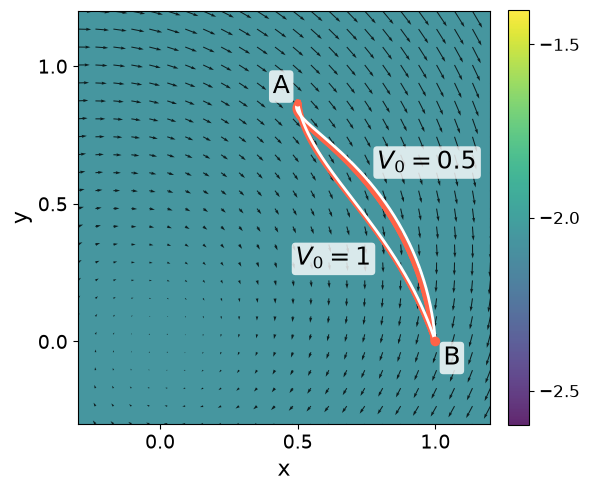

In [7]:
plot_figure(env2, trajectories[0:10] + trajectories2[0:10] + [track_opt] + [track2_opt], time=1.53)